In [75]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

import numpy as np
import matplotlib.pyplot as plt

In [76]:
def load_coffee_data():
    """ Creates a coffee roasting data set.
        roasting duration: 12-15 minutes is best
        temperature range: 175-260C is best
    """
    rng = np.random.default_rng(2)
    X = rng.random(400).reshape(-1, 2)
    X[:, 1] = X[:, 1] * 4 + 11.5          # duration: 11.5-15.5 minutes
    X[:, 0] = X[:, 0] * (285 - 150) + 150  # temperature: 150-285 Celsius
    Y = np.zeros(len(X))

    i = 0
    for t, d in X:
        y = -3 / (260 - 175) * t + 21
        if (t > 175 and t < 260 and d > 12 and d < 15 and d <= y):
            Y[i] = 1
        else:
            Y[i] = 0
        i += 1

    return (X, Y.reshape(-1, 1))

X, Y = load_coffee_data()

In [77]:
print(f'{X.shape},{Y.shape}')

(200, 2),(200, 1)


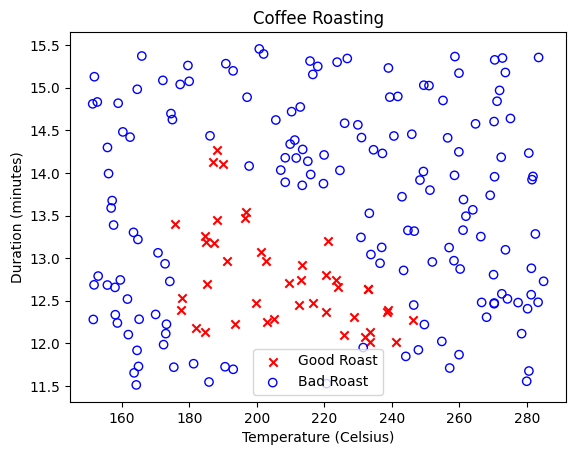

In [78]:
def plot_data(X, Y):
    pos = Y[:, 0] == 1   # good roast
    neg = Y[:, 0] == 0   # bad roast

    plt.scatter(X[pos, 0], X[pos, 1], marker='x', c='red', label='Good Roast')
    plt.scatter(X[neg, 0], X[neg, 1], marker='o', facecolors='none', edgecolors='blue', label='Bad Roast')

    plt.title('Coffee Roasting')
    plt.xlabel('Temperature (Celsius)')
    plt.ylabel('Duration (minutes)')
    plt.legend()
    plt.show()

plot_data(X, Y)

In [79]:
print(f"Temperature Max, Min pre normalization: {np.max(X[:,0]):0.2f}, {np.min(X[:,0]):0.2f}")
print(f"Duration    Max, Min pre normalization: {np.max(X[:,1]):0.2f}, {np.min(X[:,1]):0.2f}")
norm_l = tf.keras.layers.Normalization(axis=-1)
norm_l.adapt(X)  # learns mean, variance
Xn = norm_l(X)
print(f"Temperature Max, Min post normalization: {np.max(Xn[:,0]):0.2f}, {np.min(Xn[:,0]):0.2f}")
print(f"Duration    Max, Min post normalization: {np.max(Xn[:,1]):0.2f}, {np.min(Xn[:,1]):0.2f}")

Temperature Max, Min pre normalization: 284.99, 151.32
Duration    Max, Min pre normalization: 15.45, 11.51
Temperature Max, Min post normalization: 1.66, -1.69
Duration    Max, Min post normalization: 1.79, -1.70


(200000, 2),(200000, 1)


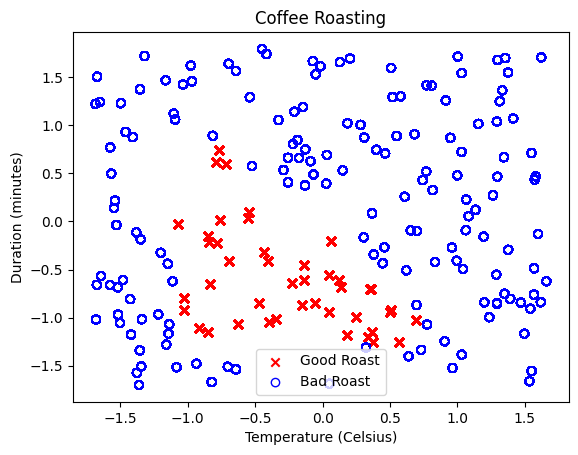

In [80]:
Xt=np.tile(Xn,(1000,1))
Yt=np.tile(Y,(1000,1))
print(f"{Xt.shape},{Yt.shape}")
plot_data(Xt, Yt)

In [96]:
tf.keras.utils.set_random_seed(123)

model = Sequential([
    tf.keras.Input(shape=(2,)),
    Dense(10, activation='relu', name='L1'),
    Dense(1,activation='linear',name='L2')
])

W1, _ = model.get_layer("L1").get_weights()
print(W1)

[[ 0.23197168  0.00849813  0.10651523  0.39210743 -0.5033227  -0.04713398
   0.38372535 -0.01396155  0.26035172 -0.30603805]
 [ 0.217543   -0.39237267  0.1975401  -0.32248288  0.14700955 -0.0240308
   0.51613253  0.6255887  -0.57203996  0.08413154]]


In [97]:
model.summary()

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ L1 (Dense)                           │ (None, 10)                  │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ L2 (Dense)                           │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 41 (164.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)

In [98]:
W1, b1 = model.get_layer("L1").get_weights()

print(W1)
print(b1)

[[ 0.23197168  0.00849813  0.10651523  0.39210743 -0.5033227  -0.04713398
   0.38372535 -0.01396155  0.26035172 -0.30603805]
 [ 0.217543   -0.39237267  0.1975401  -0.32248288  0.14700955 -0.0240308
   0.51613253  0.6255887  -0.57203996  0.08413154]]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [99]:
hidden_model = tf.keras.Model(
    inputs=model.inputs,
    outputs=model.get_layer("L1").output
)

A = hidden_model.predict(Xn)

print(A[:10])
print("Fraction of zeros =", np.mean(A == 0))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
[[0.0000000e+00 2.4907979e-01 0.0000000e+00 0.0000000e+00 3.2407090e-01
  5.5025104e-02 0.0000000e+00 0.0000000e+00 1.5619519e-01 2.0047778e-01]
 [0.0000000e+00 5.5226582e-01 0.0000000e+00 8.5146034e-01 0.0000000e+00
  0.0000000e+00 0.0000000e+00 0.0000000e+00 1.0611210e+00 0.0000000e+00]
 [2.6128116e-01 0.0000000e+00 2.0508768e-01 0.0000000e+00 0.0000000e+00
  0.0000000e+00 5.6842202e-01 5.4096556e-01 0.0000000e+00 0.0000000e+00]
 [0.0000000e+00 5.8542621e-01 0.0000000e+00 6.3842393e-02 3.2259408e-01
  8.7491207e-02 0.0000000e+00 0.0000000e+00 5.8480853e-01 2.0411320e-01]
 [0.0000000e+00 0.0000000e+00 3.8288388e-02 0.0000000e+00 4.8840997e-01
  2.2322096e-02 1.6816080e-02 3.9856982e-01 0.0000000e+00 2.9371482e-01]
 [0.0000000e+00 4.6415770e-01 0.0000000e+00 4.5123672e-01 0.0000000e+00
  1.9795878e-02 0.0000000e+00 0.0000000e+00 7.2160739e-01 0.0000000e+00]
 [8.4342077e-02 0.0000000e+00 1.0332804e-01 0.0000000e+00 2.2651401e-01
  0.0000000e+00 2.42

In [93]:
W1, b1 = model.get_layer("L1").get_weights()
W2, b2 = model.get_layer("L2").get_weights()
print(f"W1{W1.shape}:\n", W1, f"\nb1{b1.shape}:", b1)
print(f"W2{W2.shape}:\n", W2, f"\nb2{b2.shape}:", b2)

W1(2, 3):
 [[ 0.35936904  0.01316524  0.1650126 ]
 [ 0.60745037 -0.77974427 -0.07301962]] 
b1(3,): [0. 0. 0.]
W2(3, 1):
 [[ 1.1677035]
 [-1.1527089]
 [-0.6369024]] 
b2(1,): [0.]


In [100]:
model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
)


In [101]:
model.fit(
    Xt,Yt,
    epochs=10,
)

Epoch 1/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 620us/step - loss: 0.0537
Epoch 2/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 621us/step - loss: 0.0102
Epoch 3/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 620us/step - loss: 0.0039
Epoch 4/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 631us/step - loss: 0.0018
Epoch 5/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 618us/step - loss: 0.0012
Epoch 6/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 622us/step - loss: 7.4258e-04
Epoch 7/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 641us/step - loss: 9.5619e-04
Epoch 8/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 621us/step - loss: 7.3628e-04
Epoch 9/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 625us/step - loss: 1.0772e-04
Epoch 10/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 4s 640us/step - loss: 0.0011


In [102]:
W1, b1 = model.get_layer("L1").get_weights()
W2, b2 = model.get_layer("L2").get_weights()
print("W1:\n", W1, "\nb1:", b1)
print("W2:\n", W2, "\nb2:", b2)

W1:
 [[ 2.25123158e-03  4.65201229e-01  4.45922422e+00  4.06873560e+00
  -4.48245525e+00  4.43393707e+00  1.02317356e-01  4.29647827e+00
   2.02247310e+00 -5.59431124e+00]
 [-2.08655998e-04 -6.31626177e+00  3.53319550e+00  3.89668965e+00
   1.76244211e+00  3.03709316e+00  2.15652004e-01  4.14265108e+00
   4.16883802e+00  6.45411253e-01]] 
b1: [-0.20698914 -6.5861354   1.3142573   1.351859   -2.1170504   1.1448158
 -0.28238016  1.4473734   7.1942015  -5.0366197 ]
W2:
 [[  0.52410877]
 [-20.798065  ]
 [-18.903942  ]
 [-24.767595  ]
 [-10.35082   ]
 [-14.00883   ]
 [  0.3727214 ]
 [-23.588848  ]
 [ 11.38423   ]
 [-27.019588  ]] 
b2: [5.548713]


In [103]:
X_test = np.array([
    [200,13.9],  # positive example
    [200,17]])   # negative example
X_testn = norm_l(X_test)
predictions = model.predict(X_testn)
print("predictions = \n", predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
predictions = 
 [[  17.136292]
 [-736.4387  ]]


In [104]:
yhat = np.zeros_like(predictions)
for i in range(len(predictions)):
    if predictions[i] >= 0.5:
        yhat[i] = 1
    else:
        yhat[i] = 0
print(f"decisions = \n{yhat}")

decisions = 
[[1.]
 [0.]]


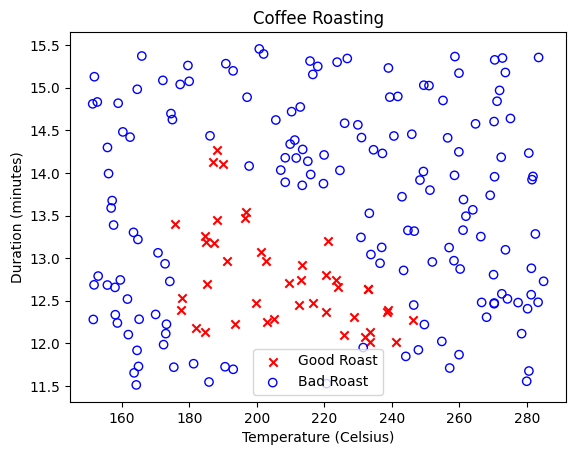

In [105]:
plot_data(X,Y)

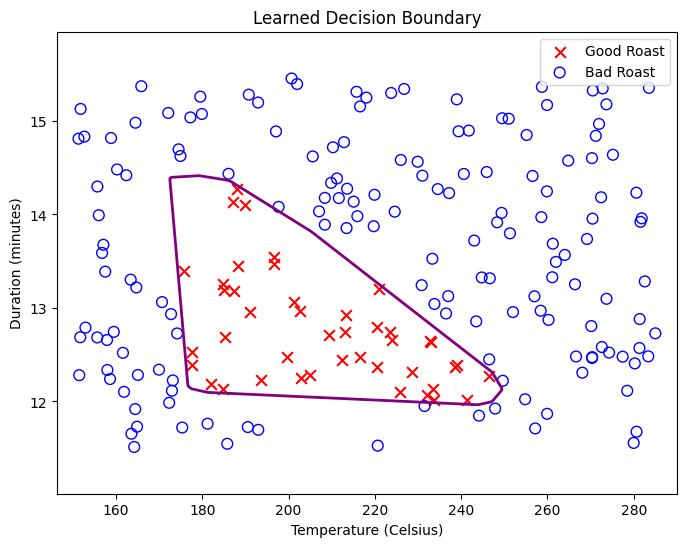

In [106]:
import numpy as np
import matplotlib.pyplot as plt

def plot_decision_boundary(model, norm_l, X, Y):
    # Create a grid covering the range of your original data
    temp_min, temp_max = X[:, 0].min() - 5, X[:, 0].max() + 5
    dur_min, dur_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(temp_min, temp_max, 300),
        np.linspace(dur_min, dur_max, 300)
    )

    # Flatten grid into (N, 2) points, normalize, predict
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    grid_points_norm = norm_l(grid_points)
    preds = model.predict(grid_points_norm, verbose=0)
    preds = preds.reshape(xx.shape)

    # Plot filled contour for the decision regions
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, preds, levels=[0, 0.5, 1], colors=['#FFCCCC', '#CCE5FF'], alpha=0.6)
    plt.contour(xx, yy, preds, levels=[0.5], colors='purple', linewidths=2)  # the boundary line itself

    # Overlay your original data points
    good = Y[:, 0] == 1
    bad = Y[:, 0] == 0
    plt.scatter(X[good, 0], X[good, 1], c='red', marker='x', label='Good Roast', s=60)
    plt.scatter(X[bad, 0], X[bad, 1], facecolors='none', edgecolors='blue', label='Bad Roast', s=60)

    plt.xlabel('Temperature (Celsius)')
    plt.ylabel('Duration (minutes)')
    plt.title('Learned Decision Boundary')
    plt.legend()
    plt.show()

plot_decision_boundary(model, norm_l, X, Y)